# Cascaded ALPS Reconstruction for 2-Channel MRI

**Pipeline:**
1. Load a fully-sampled 2-channel (Real + Imaginary) MRI slice
2. Simulate the forward problem — build masks, compute k-space, apply undersampling
3. **CG reconstruction** — conjugate-gradient baseline for each cascade
4. **Stage 1 ALPS** — 96×96 posterior sampling from central k-space crop
5. **Stage 2 ALPS** — 384×384 posterior sampling conditioned on Stage 1
6. Visualise and compare all results

Run from the `cascade_diffusion_mri-main/` directory.

## 1. Environment Setup

In [49]:
import os, sys, pickle, math
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Paths ─────────────────────────────────────────────────────────────────────
# Notebooks have no __file__, and the working directory differs between Jupyter
# (the notebook's folder) and VSCode (the workspace root). So instead of relying
# on either, locate the project root by walking up until we find its marker dirs.
def _find_project_root(start):
    p = os.path.abspath(start)
    while True:
        if os.path.isdir(os.path.join(p, 'edm_repo')) and \
           os.path.isdir(os.path.join(p, 'alps')):
            return p
        parent = os.path.dirname(p)
        if parent == p:            # reached filesystem root
            return None
        p = parent

# Search from the cwd, then from a few likely starting points.
PROJECT_ROOT = (
    _find_project_root(os.getcwd())
    or _find_project_root(os.path.join(os.getcwd(), 'alps'))
    or _find_project_root(os.path.join(os.getcwd(), '..'))
)
if PROJECT_ROOT is None:
    # Fallback: set manually if auto-detection fails.
    # PROJECT_ROOT = '/home2/wzr8sn/Work/cascade_diffusion_mri'
    raise RuntimeError(
        'Could not locate project root (a dir containing both edm_repo/ and '
        'alps/). Set PROJECT_ROOT manually in this cell.'
    )

for _p in [
    os.path.join(PROJECT_ROOT, 'edm_repo'),
    os.path.join(PROJECT_ROOT, 'scripts'),
    PROJECT_ROOT,
]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

print(f'Project root : {PROJECT_ROOT}')

Project root : /home2/wzr8sn/Work/cascade_diffusion_mri


In [50]:
# Needed so pickle can reconstruct the SR model class
from edm_sr_model import EDMSRPrecond          # noqa
from training.networks import EDMPrecond        # noqa

from alps.operators import (MRIOperator, avg_pool_complex,
                            make_cartesian_mask, crop_kspace_center)
from alps.denoiser  import BaseDenoiser, SRDenoiser
from alps.sampling  import ALPSOptions, ALPS, cascaded_ALPS, giveTsteps

print('Imports OK')

Imports OK


## 2. Configuration

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  EDIT THESE PATHS / SETTINGS
# ═══════════════════════════════════════════════════════════════════════════════

GPU_ID = 0
device = torch.device(f'cuda:{GPU_ID}' if torch.cuda.is_available() else 'cpu')

# Checkpoint paths — the trained MRI EDM checkpoints live here:
CKPT_ROOT = '/CBIG-Standard-ECE/Sahil/mri_cascaded_diffusion/checkpoints'
# Latest available snapshots (numbers are kimg = cur_nimg // 1000).
BASE_CKPT = os.path.join(CKPT_ROOT, 'edm_mri_base_96/network-snapshot-027597.pkl')
SR_CKPT   = os.path.join(CKPT_ROOT, 'edm_mri_sr_384/network-snapshot-002637.pkl')

# Data — RAW fastMRI AXT2 .pkl with multi-coil k-space + coil-sensitivity maps:
#   {'cropped_kspace': (S, C, 384, 384) complex,
#    'coil_sensitivity_maps': (S, C, 384, 384) complex,
#    'ground_truth': (S, 384, 384) RSS magnitude}
# The reconstruction now uses the multi-coil SENSE forward model, so we need the
# raw .pkl (the preprocessed AXT2_normalized .pt has no coils).
DATA_PT   = '/CBIG-Standard-ECE/aniket/FastMRI_brain_data_all/AXT2/file_brain_AXT2_200_6002235.pkl'
SLICE_IDX = 2      # which slice to reconstruct

# Forward model
ACCELERATION  = 1      # Cartesian undersampling factor
ACS_FRACTION  = 0.04   # fraction of k-space centre always acquired
ETA           = 0.1   # noise std
SEED          = 42

# ALPS hyperparameters
SIGMA_MAX   = 5.0
SIGMA_MIN   = 0.002
RHO         = 7.0
STEPS_BASE  = 20   # noise levels for Stage 1
STEPS_SR    = 20   # noise levels for Stage 2
K           = 5    # Langevin inner steps per noise level

# SENSE data-consistency: CG iterations per PreCondition solve.
# Low-σ steps (which set final quality) converge in a few iters; high-σ steps
# are inexact but prior-dominated. 10–15 is a good range.
CG_ITERS    = 5

print(f'Device        : {device}')
print(f'Acceleration  : {ACCELERATION}×')
print(f'ALPS steps    : Stage1={STEPS_BASE}, Stage2={STEPS_SR}, K={K}, CG_iters={CG_ITERS}')

Device        : cuda:0
Acceleration  : 1×
ALPS steps    : Stage1=10, Stage2=10, K=5, CG_iters=5


## 3. Load MRI Slice

In [52]:
def _enable_numpy2_pickle_compat():
    """
    Allow unpickling NumPy>=2.0 pickles under an older NumPy (<2.0).

    NumPy 2.0 renamed the private package ``numpy.core`` → ``numpy._core``, so
    arrays pickled with NumPy 2.x reference ``numpy._core.*`` which an older
    NumPy can't import. We alias the submodules back to ``numpy.core.*``.
    No-op when ``numpy._core`` already exists.
    """
    import importlib, pkgutil
    try:
        import numpy._core  # noqa: F401  (NumPy>=2.0, or 1.26 shim)
        import numpy._core.multiarray  # noqa: F401  (ensure it's importable)
        return
    except ModuleNotFoundError:
        pass
    import numpy.core as _np_core
    sys.modules.setdefault('numpy._core', _np_core)
    for _, modname, _ in pkgutil.iter_modules(_np_core.__path__):
        try:
            sys.modules.setdefault('numpy._core.' + modname,
                                   importlib.import_module('numpy.core.' + modname))
        except Exception:
            pass

def _ifft2c_np(x):
    """Centred orthonormal 2D inverse FFT over the last two axes (numpy complex)."""
    return np.fft.fftshift(
        np.fft.ifft2(np.fft.ifftshift(x, axes=(-2, -1)), norm='ortho'),
        axes=(-2, -1),
    )

def load_multicoil(path, slice_idx):
    """
    Load one slice of raw fastMRI multi-coil data.

    Returns
    -------
    kspace_mc : (1, C, 384, 384) complex   multi-coil k-space (normalised)
    csm       : (1, C, 384, 384) complex   coil-sensitivity maps
    x_gt      : (1, 2, 384, 384) float32    SENSE coil-combined image (mag ≤ 1)
    """
    _enable_numpy2_pickle_compat()           # raw .pkl was written with NumPy 2.x
    with open(path, 'rb') as f:
        o = pickle.load(f)
    ksp = torch.from_numpy(o['cropped_kspace'][slice_idx]).to(torch.complex64)[None]
    csm = torch.from_numpy(o['coil_sensitivity_maps'][slice_idx]).to(torch.complex64)[None]
    # SENSE coil-combine → complex image, normalise so max magnitude = 1
    comb  = (csm.conj() * torch.from_numpy(_ifft2c_np(o['cropped_kspace'][slice_idx])[None]).to(torch.complex64)).sum(1)
    scale = comb.abs().max()
    ksp   = ksp / scale
    comb  = comb / scale
    x_gt  = torch.stack([comb.real, comb.imag], dim=1)   # (1, 2, 384, 384)
    return ksp, csm, x_gt

kspace_mc, csm, x_gt = load_multicoil(DATA_PT, SLICE_IDX)
kspace_mc = kspace_mc.to(device); csm = csm.to(device); x_gt = x_gt.to(device)

print(f'File   : {DATA_PT}')
print(f'k-space: {tuple(kspace_mc.shape)}  ({kspace_mc.shape[1]} coils)  dtype={kspace_mc.dtype}')
print(f'csm    : {tuple(csm.shape)}')
print(f'x_gt   : {tuple(x_gt.shape)}  (SENSE combined)  mag_max={torch.sqrt(x_gt[:,0]**2+x_gt[:,1]**2).max():.3f}')

File   : /CBIG-Standard-ECE/aniket/FastMRI_brain_data_all/AXT2/file_brain_AXT2_200_6002235.pkl
k-space: (1, 20, 384, 384)  (20 coils)  dtype=torch.complex64
csm    : (1, 20, 384, 384)
x_gt   : (1, 2, 384, 384)  (SENSE combined)  mag_max=1.000


## 4. Simulate Forward Problem

### 4.1 Compute fully-sampled k-space

In [53]:
def image_to_kspace(x: torch.Tensor) -> torch.Tensor:
    """(B,2,H,W) single-channel image → (B,2,H,W) k-space (display helper)."""
    xc = torch.complex(x[:, 0], x[:, 1])
    kc = torch.fft.fft2(xc, norm='ortho')
    return torch.stack([kc.real, kc.imag], dim=1)

def kspace_to_image(k: torch.Tensor) -> torch.Tensor:
    """(B,2,H,W) k-space → (B,2,H,W) image (display helper)."""
    kc = torch.complex(k[:, 0], k[:, 1])
    xc = torch.fft.ifft2(kc, norm='ortho')
    return torch.stack([xc.real, xc.imag], dim=1)

# The acquisition is the multi-coil k-space loaded above (the real measurement).
kspace_full = kspace_mc   # (1, C, 384, 384) complex
print(f'Multi-coil k-space: {tuple(kspace_full.shape)}  ({kspace_full.shape[1]} coils)')

Multi-coil k-space: (1, 20, 384, 384)  (20 coils)


### 4.2 Build operators and extract measurements

In [54]:
# Average-pool the coil maps and build masks *outside* the operator.
# Stage 1 works at 96×96; fft_scale = 384/96 = 4 so the pooled-image forward
# model reproduces the measured 384×384 k-space centre.
FULL = kspace_full.shape[-1]        # 384
LOW  = FULL // 4                     # 96
POOL = FULL // LOW                   # 4

csm_96 = avg_pool_complex(csm, POOL)                                 # (1, C, 96, 96)

# A single Cartesian mask; the 96×96 Stage-1 mask is its central crop so the
# two stages sample exactly the same phase-encode lines in the k-space centre.
mask_384 = make_cartesian_mask(FULL, ACCELERATION, ACS_FRACTION, SEED)
mask_96  = crop_kspace_center(mask_384, LOW)

# Stage 1 SENSE operator — 96×96 (pooled image + pooled coil maps)
A1 = MRIOperator(
    csm       = csm_96,
    mask      = mask_96,
    eta       = ETA,
    cg_iters  = CG_ITERS,
    fft_scale = FULL / LOW,          # = 4
    device    = device,
)

# Stage 2 SENSE operator — 384×384 (full multi-coil model)
A2 = MRIOperator(
    csm       = csm,
    mask      = mask_384,
    eta       = ETA,
    cg_iters  = CG_ITERS,
    fft_scale = 1.0,
    device    = device,
)

# Multi-coil measurements (mask applied inside get_measurements; y1 is the
# masked centre crop of the real k-space). The acquired k-space is already
# noisy, so we do NOT add synthetic measurement noise — this keeps the forward
# problem identical to cascaded_ALPS so the two paths agree.
y1 = A1.get_measurements(kspace_full)             # (1, C, 96, 96)  complex
y2 = A2.get_measurements(kspace_full)             # (1, C, 384, 384) complex

print(f'y1 (Stage 1 multi-coil measurements): {tuple(y1.shape)}')
print(f'y2 (Stage 2 multi-coil measurements): {tuple(y2.shape)}')

[MRIOperator] 96×96 SENSE, 20 coils, fft_scale=4, 96/96 lines acquired (actual 1.0×)
[MRIOperator] 384×384 SENSE, 20 coils, fft_scale=1, 383/384 lines acquired (actual 1.0×)
y1 (Stage 1 multi-coil measurements): (1, 20, 96, 96)
y2 (Stage 2 multi-coil measurements): (1, 20, 384, 384)


In [55]:
def load_model(pkl_path, device):
    print(f'Loading: {pkl_path}')
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)
    net = data['ema'].to(device).eval()
    n_p = sum(p.numel() for p in net.parameters())
    print(f'  {n_p:,} params | img_resolution={net.img_resolution} | img_channels={net.img_channels}')
    del data
    torch.cuda.empty_cache()
    return net

net_base = load_model(BASE_CKPT, device)
net_sr   = load_model(SR_CKPT,   device)

Loading: /CBIG-Standard-ECE/Sahil/mri_cascaded_diffusion/checkpoints/edm_mri_base_96/network-snapshot-027597.pkl
  60,483,714 params | img_resolution=96 | img_channels=2
Loading: /CBIG-Standard-ECE/Sahil/mri_cascaded_diffusion/checkpoints/edm_mri_sr_384/network-snapshot-002637.pkl
  50,512,450 params | img_resolution=384 | img_channels=2


Run Full Cascade via `cascaded_ALPS`

The `cascaded_ALPS` convenience function wraps Stages 1 and 2 together.
Useful when you don't need intermediate results.

In [56]:
opts_base = ALPSOptions(
    num_steps = STEPS_BASE,
    sigma_max = SIGMA_MAX,
    sigma_min = SIGMA_MIN,
    rho       = RHO,
    K         = K,
)

opts_sr = ALPSOptions(
    num_steps = STEPS_SR,
    sigma_max = SIGMA_MAX,
    sigma_min = SIGMA_MIN,
    rho       = RHO,
    K         = K,
)

result = cascaded_ALPS(
    multicoil_kspace_384 = kspace_mc,
    csm_384              = csm,
    net_base             = net_base,
    net_sr               = net_sr,
    opts_base            = opts_base,
    opts_sr              = opts_sr,
    acceleration         = ACCELERATION,
    acs_fraction         = ACS_FRACTION,
    eta                  = ETA,
    seed                 = SEED,
    cg_iters             = CG_ITERS,
    device               = device,
    verbose              = True,
)
x96_v2  = result['x96']
x384_v2 = result['x384']

[MRIOperator] 96×96 SENSE, 20 coils, fft_scale=4, 96/96 lines acquired (actual 1.0×)
[MRIOperator] 384×384 SENSE, 20 coils, fft_scale=1, 383/384 lines acquired (actual 1.0×)
  Stage 1: 96×96 reconstruction from central k-space
  10 noise levels, K=5 inner steps
  Stage 1 done.  x96 shape: (1, 2, 96, 96)

  Stage 2: 384×384 reconstruction conditioned on 96×96
  10 noise levels, K=5 inner steps
  Stage 2 done.  x384 shape: (1, 2, 384, 384)



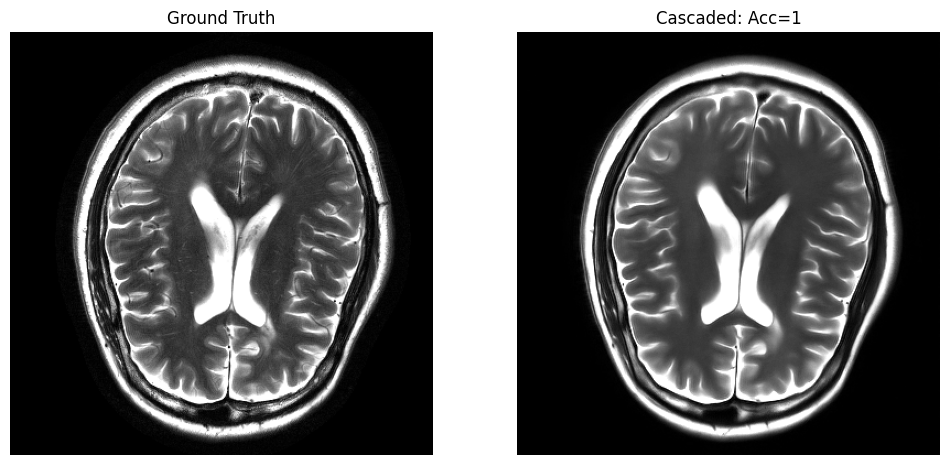

Saved summary figure.


In [57]:
plt.subplots(1, 2, figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(magnitude(x_gt), cmap='gray',vmax=0.5)
plt.title('Ground Truth', fontsize=12)
plt.axis('off')

plt.subplot(1,2, 2)
plt.imshow(magnitude(x384_v2), cmap='gray',vmax=0.5)
plt.title('Cascaded: Acc='+str(ACCELERATION), fontsize=12)
plt.axis('off')

plt.savefig(os.path.join(PROJECT_ROOT, 'outputs/alps_summary.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved summary figure.')
